# Distillation Pipeline

In [ ]:
selected_models = ["bert-base-uncased"]

## 1. Setup

### Imports

In [1]:
import os
import time
import random
import copy
import json
from dataclasses import dataclass
from datetime import timedelta

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

### Config and Env Setup

In [65]:
# config and env setup
config_path = os.path.join(os.getcwd(), "distillation_config.json")
with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

In [ ]:
# Configuration Parameters

SEED = int(config["seed"])

# feature extraction parameters
FEATURE_BATCH_SIZE = int(config["feature_extraction"]["batch_size"])
FEATURE_MAX_LENGTH = int(config["feature_extraction"]["max_length"])

LATENCY_BATCH_SIZE = int(config["evaluation"]["latency_batch_size"])

# training parameters
GRAD_CLIP = float(config["training"]["gradient_clip_norm"])
MIN_DELTA = float(config["training"]["min_delta"])
OPTIMIZER_NAME = str(config["training"]["optimizer"])

# directories
PIPELINE_METRICS_DIR = config["output"]["pipeline_metrics_dir"]

# distillation configuration
distillation_config = config.get("distillation", {})
DISTILLATION_ENABLED = config["distillation"]["enabled"]
DISTILLATION_ALPHA = float(config["distillation"]["alpha"])
DISTILLATION_TEMPERATURE = float(config["distillation"]["temperature"])

# model-specific configurations
models = [m for m in config["models"] if m["model_id"] in selected_models]
model_configs = {
    model_name: cfg 
    for model_name, cfg in config["model_config"].items() if model_name in [m["name"] for m in models]}
print("Loaded model-specific configurations:")

for model_name, model_cfg in model_configs.items():
    print(f"\nModel: {model_name}")
    for param, value in model_cfg.items():
        print(f"  {param}: {value}")


# student model configuration
student_config = distillation_config.get("student_config", {})
STUDENT_HIDDEN_DIMS = student_config.get("hidden_dims", [256, 128])
STUDENT_DROPOUT = float(student_config.get("dropout", 0.3))
STUDENT_LR = float(student_config.get("learning_rate", 0.001))
STUDENT_BATCH_SIZE = int(student_config.get("batch_size", 64))
STUDENT_EPOCHS = int(student_config.get("epochs", 50))
STUDENT_PATIENCE = int(student_config.get("patience", 10))
DISTILLATION_OUTPUT_DIR = distillation_config.get("output_dir", "distillation_metrics")

Loaded model-specific configurations:

Model: BERT
  epochs_options: [200]
  batch_size_options: [128]
  hidden_dims_options: [[512, 256, 128]]
  dropout_options: [0.1]
  lr_options: [0.0003]
  n_splits: 5
  patience: 10
  show_epoch_progress: True

Model: RoBERTa
  epochs_options: [200]
  batch_size_options: [64]
  hidden_dims_options: [[512, 256, 128]]
  dropout_options: [0.1]
  lr_options: [0.0003]
  n_splits: 5
  patience: 10
  show_epoch_progress: True

Model: DistilBERT
  epochs_options: [200]
  batch_size_options: [128]
  hidden_dims_options: [[512, 256, 128]]
  dropout_options: [0.1]
  lr_options: [0.0003]
  n_splits: 5
  patience: 10
  show_epoch_progress: True


### Check GPU

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
CUDA version: 12.1


## 2. Data Loading and Preprocessing

In [5]:
dataset = config["dataset"]["general_sentiment_analysis_dataset"]

data_path = os.path.join(os.getcwd(), dataset["dataset_file_name"])
df = pd.read_json(data_path, lines=True)
df["label"] = df["label"].astype(int)
df.head()

,id,text,label,sentiment
0,9536,"Cooking microwave pizzas, yummy",2,positive
1,6135,Any plans of allowing sub tasks to show up in ...,1,neutral
2,17697,"I love the humor, I just reworded it. Like sa...",2,positive
3,14182,naw idk what ur talkin about,1,neutral
4,17840,That sucks to hear. I hate days like that,0,negative


## 3. Train/Validation/Test Split

In [6]:
texts = df["text"].astype(str).to_numpy()
labels = df["label"].to_numpy()

test_size = dataset["test_size"]
val_split = dataset["val_split"]

x_train, x_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=test_size, random_state=SEED, stratify=labels
)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=val_split, random_state=SEED, stratify=y_temp
)

num_classes = len(np.unique(labels))
print(f"Train: {len(x_train)}, Val: {len(x_val)}, Test: {len(x_test)}")
print(f"Number of classes: {num_classes}")

Train: 21984, Val: 2748, Test: 2749
Number of classes: 3


## 4. Feature Extraction with Transformer Encoders

In [7]:
notebook_start_time = time.perf_counter()

### Dataset Class

In [8]:
@dataclass
class ModelSpec:
    name: str
    model_id: str

In [9]:
class TextDataset(Dataset):
    def __init__(self, texts, labels=None):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        if self.labels is None:
            return self.texts[idx]
        return self.texts[idx], int(self.labels[idx])

In [10]:
def make_text_loader(texts, labels=None, batch_size=32):
    ds = TextDataset(texts, labels)
    return DataLoader(ds, batch_size=batch_size, shuffle=False)

### Feature Extractor

In [79]:
def extract_features(model_id, texts, batch_size=32, max_length=256):
    """Extract CLS or pooled features using a transformer encoder."""
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModel.from_pretrained(model_id).to(device)
    model.eval()

    features = []
    loader = make_text_loader(texts, batch_size=batch_size)
    with torch.no_grad():
        for batch_texts in loader:
            encoded = tokenizer(
                list(batch_texts),
                max_length=max_length,
                padding=True,
                truncation=True,
                return_tensors="pt"
            ).to(device)

            outputs = model(**encoded)
            if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
                batch_features = outputs.pooler_output
            else:
                batch_features = outputs.last_hidden_state[:, 0, :]

            features.append(batch_features.detach().cpu())

    features = torch.cat(features, dim=0)
    return features

### Fetch Models

In [102]:
models

[{'name': 'BERT', 'model_id': 'bert-base-uncased'},
 {'name': 'RoBERTa', 'model_id': 'roberta-base'},
 {'name': 'DistilBERT', 'model_id': 'distilbert-base-uncased'}]

In [106]:
models

[{'name': 'BERT', 'model_id': 'bert-base-uncased'},
 {'name': 'RoBERTa', 'model_id': 'roberta-base'},
 {'name': 'DistilBERT', 'model_id': 'distilbert-base-uncased'}]

In [112]:
model_specifications = [ModelSpec(model["name"], model["model_id"]) for model in models]
feature_cache = {}

### Extract Features

In [114]:
for spec in model_specifications:
    print(f"=========Extracting features with {spec.name}...")
    feature_cache[spec.name] = {
        "train": extract_features(
            spec.model_id,
            x_train,
            batch_size=FEATURE_BATCH_SIZE,
            max_length=FEATURE_MAX_LENGTH,
        ),
        "val": extract_features(
            spec.model_id,
            x_val,
            batch_size=FEATURE_BATCH_SIZE,
            max_length=FEATURE_MAX_LENGTH,
        ),
        "test": extract_features(
            spec.model_id,
            x_test,
            batch_size=FEATURE_BATCH_SIZE,
            max_length=FEATURE_MAX_LENGTH,
        ),
    }
    print(f"{spec.name} train feature shape: {feature_cache[spec.name]['train'].shape}")
    print(f"{spec.name} val feature shape: {feature_cache[spec.name]['val'].shape}")
    print(f"{spec.name} test feature shape: {feature_cache[spec.name]['test'].shape}")

=========Extracting features with BERT...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERT train feature shape: torch.Size([21984, 768])
DistilBERT val feature shape: torch.Size([2748, 768])
DistilBERT test feature shape: torch.Size([2749, 768])


## 5. Neural Classifier

In [85]:
class FeatureClassifier(nn.Module):
    """MLP for fixed-size transformer features."""
    def __init__(self, input_dim, num_classes, hidden_dims, dropout=0.3):
        super().__init__()
        if not hidden_dims:
            raise ValueError("hidden_dims must contain at least one layer size")

        layers = []
        dims = [input_dim] + list(hidden_dims)
        for idx in range(len(hidden_dims)):
            layers.append(nn.Linear(dims[idx], dims[idx + 1]))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(hidden_dims[-1], num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [86]:
class FeatureDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], int(self.labels[idx])

In [87]:
def make_feature_loader(features, labels, batch_size=64, shuffle=True):
    ds = FeatureDataset(features, labels)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

## 6. Detailed Metrics Tracking System

In [88]:
class MetricsTracker:
    """Track detailed training metrics for TensorBoard-style visualization."""
    
    def __init__(self, model_name: str):
        self.model_name = model_name
        self.history = {
            'epoch': [],
            'train_loss': [],
            'train_acc': [],
            'train_precision': [],
            'train_recall': [],
            'train_f1': [],
            'val_loss': [],
            'val_acc': [],
            'val_precision': [],
            'val_recall': [],
            'val_f1': [],
            'learning_rate': [],
            'epoch_time': []
        }
        
    def log_epoch(self, epoch: int, train_metrics: dict, val_metrics: dict, 
                  lr: float, epoch_time: float):
        """Log metrics for a single epoch."""
        self.history['epoch'].append(epoch)
        self.history['train_loss'].append(train_metrics['loss'])
        self.history['train_acc'].append(train_metrics['acc'])
        self.history['train_precision'].append(train_metrics['precision'])
        self.history['train_recall'].append(train_metrics['recall'])
        self.history['train_f1'].append(train_metrics['f1'])
        self.history['val_loss'].append(val_metrics['loss'])
        self.history['val_acc'].append(val_metrics['acc'])
        self.history['val_precision'].append(val_metrics['precision'])
        self.history['val_recall'].append(val_metrics['recall'])
        self.history['val_f1'].append(val_metrics['f1'])
        self.history['learning_rate'].append(lr)
        self.history['epoch_time'].append(epoch_time)
        
    def get_dataframe(self) -> pd.DataFrame:
        """Get history as DataFrame."""
        return pd.DataFrame(self.history)
    
    def save(self, filepath: str):
        """Save metrics to CSV."""
        df = self.get_dataframe()
        # df.to_csv(filepath, index=False)
        # print(f"Saved {self.model_name} training metrics to {filepath}")
        
    def plot_metrics(self, save_path: str = None):
        """Plot training metrics."""
        df = self.get_dataframe()
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle(f'{self.model_name} Training Metrics', fontsize=16, fontweight='bold')
        
        # Loss plot
        axes[0, 0].plot(df['epoch'], df['train_loss'], label='Train Loss', marker='o')
        axes[0, 0].plot(df['epoch'], df['val_loss'], label='Val Loss', marker='s')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].set_title('Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # Accuracy plot
        axes[0, 1].plot(df['epoch'], df['train_acc'], label='Train Accuracy', marker='o')
        axes[0, 1].plot(df['epoch'], df['val_acc'], label='Val Accuracy', marker='s')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Accuracy')
        axes[0, 1].set_title('Accuracy')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        # F1 Score plot
        axes[1, 0].plot(df['epoch'], df['train_f1'], label='Train F1', marker='o')
        axes[1, 0].plot(df['epoch'], df['val_f1'], label='Val F1', marker='s')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('F1 Score')
        axes[1, 0].set_title('F1 Score')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        # Precision & Recall plot
        axes[1, 1].plot(df['epoch'], df['train_precision'], label='Train Precision', marker='o', linestyle='--')
        axes[1, 1].plot(df['epoch'], df['val_precision'], label='Val Precision', marker='s', linestyle='--')
        axes[1, 1].plot(df['epoch'], df['train_recall'], label='Train Recall', marker='^', linestyle=':')
        axes[1, 1].plot(df['epoch'], df['val_recall'], label='Val Recall', marker='v', linestyle=':')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Score')
        axes[1, 1].set_title('Precision & Recall')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        if save_path:
            # plt.savefig(save_path, dpi=300, bbox_inches='tight')
            # print(f"Saved {self.model_name} training plot to {save_path}")
            pass
        
        plt.show()

## 7. Training and Evaluation Utilities

In [89]:
def compute_detailed_metrics(all_preds, all_labels):
    """Compute accuracy, precision, recall, and F1."""
    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="weighted", zero_division=0
    )
    return {
        'acc': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [90]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    
    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        if GRAD_CLIP > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        total_loss += loss.item() * x_batch.size(0)
        all_preds.append(torch.argmax(logits, dim=1).detach().cpu())
        all_labels.append(y_batch.detach().cpu())
    
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    metrics = compute_detailed_metrics(all_preds, all_labels)
    metrics['loss'] = total_loss / len(loader.dataset)
    return metrics

In [91]:
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * x_batch.size(0)
            all_preds.append(torch.argmax(logits, dim=1).detach().cpu())
            all_labels.append(y_batch.detach().cpu())
    
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    metrics = compute_detailed_metrics(all_preds, all_labels)
    metrics['loss'] = total_loss / len(loader.dataset)
    return metrics

In [92]:
def make_optimizer(model, lr):
    opt = OPTIMIZER_NAME.strip().lower()
    if opt == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr)
    if opt == "adamw":
        return torch.optim.AdamW(model.parameters(), lr=lr)
    raise ValueError(f"Unsupported optimizer: {OPTIMIZER_NAME}")

In [93]:
def train_with_tracking(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs,
    patience=5,
    min_delta=0.0,
    verbose=True,
    metrics_tracker=None
):
    """Train model with detailed metric tracking."""
    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = -1.0
    epochs_since_improve = 0

    for epoch in range(1, epochs + 1):
        epoch_start = time.perf_counter()
        
        train_metrics = train_epoch(model, train_loader, optimizer, criterion)
        val_metrics = eval_epoch(model, val_loader, criterion)
        
        epoch_time = time.perf_counter() - epoch_start
        
        # Get current learning rate
        current_lr = optimizer.param_groups[0]['lr']
        
        # Log metrics
        if metrics_tracker:
            metrics_tracker.log_epoch(epoch, train_metrics, val_metrics, current_lr, epoch_time)
        
        if verbose:
            print(
                f"Epoch {epoch:3d}/{epochs} | "
                f"train_loss={train_metrics['loss']:.4f} train_acc={train_metrics['acc']:.4f} train_f1={train_metrics['f1']:.4f} | "
                f"val_loss={val_metrics['loss']:.4f} val_acc={val_metrics['acc']:.4f} val_f1={val_metrics['f1']:.4f} | "
                f"time={epoch_time:.2f}s"
            )

        if val_metrics['acc'] > best_val_acc + min_delta:
            best_val_acc = val_metrics['acc']
            best_state = copy.deepcopy(model.state_dict())
            epochs_since_improve = 0
        else:
            epochs_since_improve += 1
            if epochs_since_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

    return best_state, best_val_acc

In [94]:
def evaluate_model(model, loader):
    """Evaluate model and return all metrics."""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            logits = model(x_batch)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(y_batch.numpy())
    
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    metrics = compute_detailed_metrics(all_preds, all_labels)
    return metrics

In [95]:
def measure_latency(model, features, labels, batch_size=256):
    """Measure inference latency."""
    model.eval()
    loader = make_feature_loader(features, labels, batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for x_batch, _ in loader:
            _ = model(x_batch.to(device))
            break
        start = time.perf_counter()
        total = 0
        for x_batch, _ in loader:
            _ = model(x_batch.to(device))
            total += x_batch.size(0)
        end = time.perf_counter()
    return (end - start) / max(total, 1) * 1000

## 8. Train Models with Model-Specific Configurations

### Train Models

In [96]:
# Create output directory for metrics and plots

os.makedirs(PIPELINE_METRICS_DIR, exist_ok=True)

all_metrics_trackers = {}
final_results = {}
trained_teacher_models = {}  # stores trained model objects for use in distillation

In [116]:
# Train each teacher model with its specific configuration
for spec in model_specifications:
    model_name = spec.name
    print(f"\n{'='*80}")
    print(f"Training {model_name} with model-specific configuration")
    print(f"{'='*80}")


    # region - Get config and data loaders

    # Get model-specific config
    if model_name not in model_configs:
        print(f"WARNING: No config found for {model_name}, skipping...")
        continue
    
    model_cfg = model_configs[model_name]
    
    # Extract hyperparameters (taking first element from each _options list)
    epochs = model_cfg["epochs_options"][0]
    batch_size = model_cfg["batch_size_options"][0]
    hidden_dims = model_cfg["hidden_dims_options"][0]
    dropout = model_cfg["dropout_options"][0]
    lr = model_cfg["lr_options"][0]
    patience = model_cfg.get("patience", 5)
    
    print(f"Configuration:")
    print(f"  Epochs: {epochs}")
    print(f"  Batch Size: {batch_size}")
    print(f"  Hidden Dims: {hidden_dims}")
    print(f"  Dropout: {dropout}")
    print(f"  Learning Rate: {lr}")
    print(f"  Patience: {patience}")
    print()
    
    # Get features
    train_feats = feature_cache[model_name]["train"]
    val_feats = feature_cache[model_name]["val"]
    test_feats = feature_cache[model_name]["test"]
    input_dim = train_feats.shape[1]
    
    # Create data loaders
    train_loader = make_feature_loader(train_feats, y_train, batch_size=batch_size, shuffle=True)
    val_loader = make_feature_loader(val_feats, y_val, batch_size=batch_size, shuffle=False)
    test_loader = make_feature_loader(test_feats, y_test, batch_size=batch_size, shuffle=False)

    # endregion
    

    # region - Initialize model, optimizer, criterion, and metrics tracker

    # Initialize model
    model = FeatureClassifier(
        input_dim, num_classes, hidden_dims=hidden_dims, dropout=dropout
    ).to(device)
    
    optimizer = make_optimizer(model, lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    # Initialize metrics tracker
    metrics_tracker = MetricsTracker(model_name)
    
    # Train model
    print(f"Training {model_name}...")
    training_start = time.perf_counter()
    
    best_state, best_val_acc = train_with_tracking(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        epochs=epochs,
        patience=patience,
        min_delta=MIN_DELTA,
        verbose=True,
        metrics_tracker=metrics_tracker
    )

    # endregion
    
    training_time = time.perf_counter() - training_start
    
    # Load best model weights and store for distillation use
    model.load_state_dict(best_state)
    trained_teacher_models[model_name] = model
    
    # Evaluate on test set
    print(f"\nEvaluating {model_name} on test set...")
    test_metrics = evaluate_model(model, test_loader)
    
    # Measure latency
    latency_ms = measure_latency(model, test_feats, y_test, batch_size=LATENCY_BATCH_SIZE)
    
    # Calculate model size
    params = sum(p.numel() for p in model.parameters())
    size_mb = params * 4 / 1e6
    
    # Store metrics tracker
    all_metrics_trackers[model_name] = metrics_tracker
    
    # Save training history
    history_path = os.path.join(PIPELINE_METRICS_DIR, f"{model_name}_training_history.csv")
    # metrics_tracker.save(history_path)
    
    # Store final results
    final_results[model_name] = {
        'config': {
            'epochs': epochs,
            'batch_size': batch_size,
            'hidden_dims': str(hidden_dims),
            'dropout': dropout,
            'lr': lr,
            'patience': patience
        },
        'best_val_acc': best_val_acc,
        'test_acc': test_metrics['acc'],
        'test_precision': test_metrics['precision'],
        'test_recall': test_metrics['recall'],
        'test_f1': test_metrics['f1'],
        'training_time_s': training_time,
        'params': params,
        'size_mb': size_mb,
        'latency_ms': latency_ms,
        'epochs_trained': len(metrics_tracker.history['epoch'])
    }
    
    print(f"\n{model_name} Results:")
    print(f"  Best Val Accuracy: {best_val_acc:.4f}")
    print(f"  Test Accuracy: {test_metrics['acc']:.4f}")
    print(f"  Test Precision: {test_metrics['precision']:.4f}")
    print(f"  Test Recall: {test_metrics['recall']:.4f}")
    print(f"  Test F1: {test_metrics['f1']:.4f}")
    print(f"  Training Time: {training_time:.2f}s")
    print(f"  Model Size: {size_mb:.2f} MB")
    print(f"  Latency: {latency_ms:.4f} ms")
    print(f"  Epochs Trained: {len(metrics_tracker.history['epoch'])}")


Training BERT with model-specific configuration
Configuration:
  Epochs: 200
  Batch Size: 128
  Hidden Dims: [512, 256, 128]
  Dropout: 0.1
  Learning Rate: 0.0003
  Patience: 10

Training BERT...
Epoch   1/200 | train_loss=1.0613 train_acc=0.4200 train_f1=0.3706 | val_loss=0.9602 val_acc=0.5069 val_f1=0.5020 | time=0.56s
Epoch   2/200 | train_loss=0.9464 train_acc=0.5260 train_f1=0.5249 | val_loss=0.9085 val_acc=0.5502 val_f1=0.5342 | time=0.38s
Epoch   3/200 | train_loss=0.9080 train_acc=0.5555 train_f1=0.5559 | val_loss=0.9017 val_acc=0.5517 val_f1=0.5421 | time=0.41s
Epoch   4/200 | train_loss=0.8929 train_acc=0.5683 train_f1=0.5683 | val_loss=0.8489 val_acc=0.5993 val_f1=0.5992 | time=0.37s
Epoch   5/200 | train_loss=0.8838 train_acc=0.5764 train_f1=0.5771 | val_loss=0.9676 val_acc=0.5182 val_f1=0.4857 | time=0.35s
Epoch   6/200 | train_loss=0.8696 train_acc=0.5862 train_f1=0.5862 | val_loss=0.8468 val_acc=0.6008 val_f1=0.5972 | time=0.38s
Epoch   7/200 | train_loss=0.8641 train

### Visualize Training Metrics

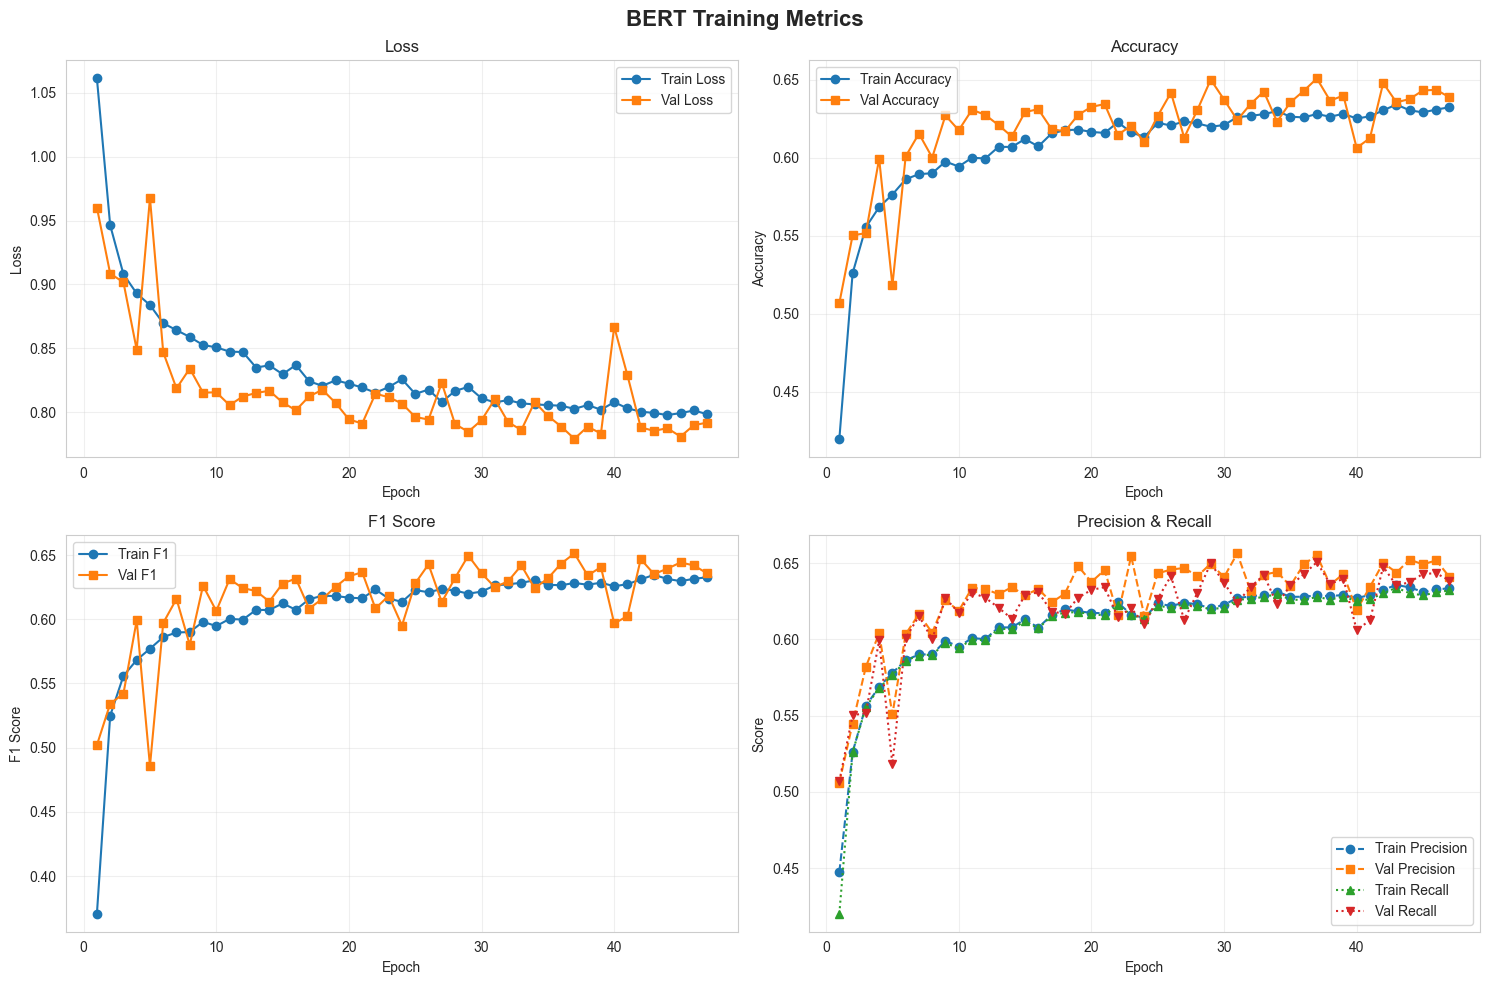

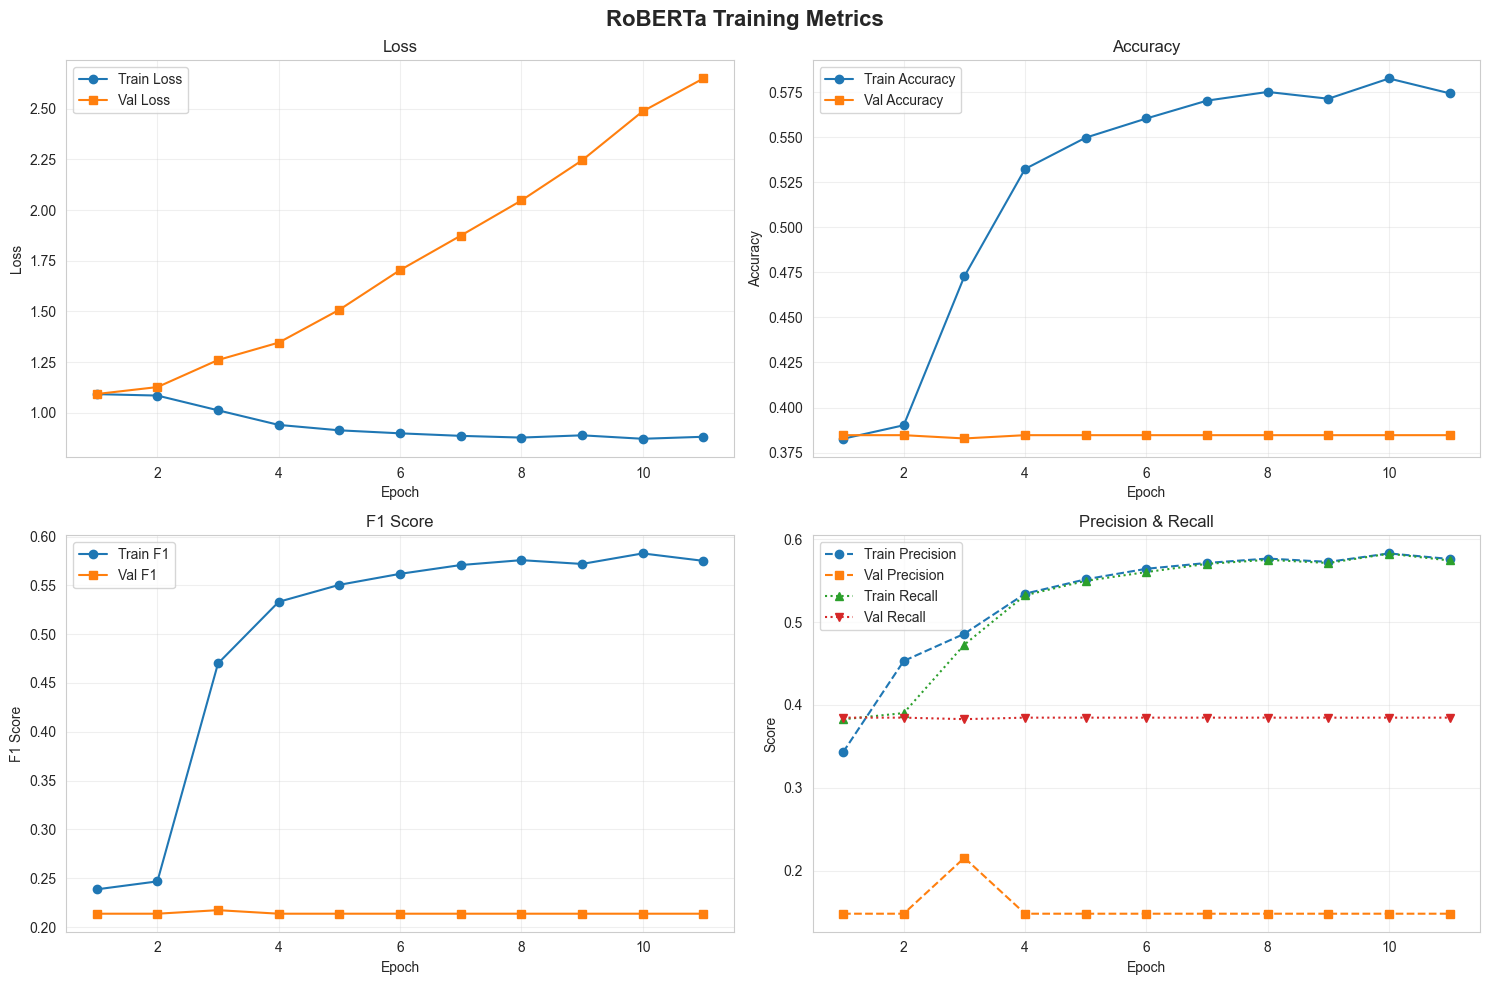

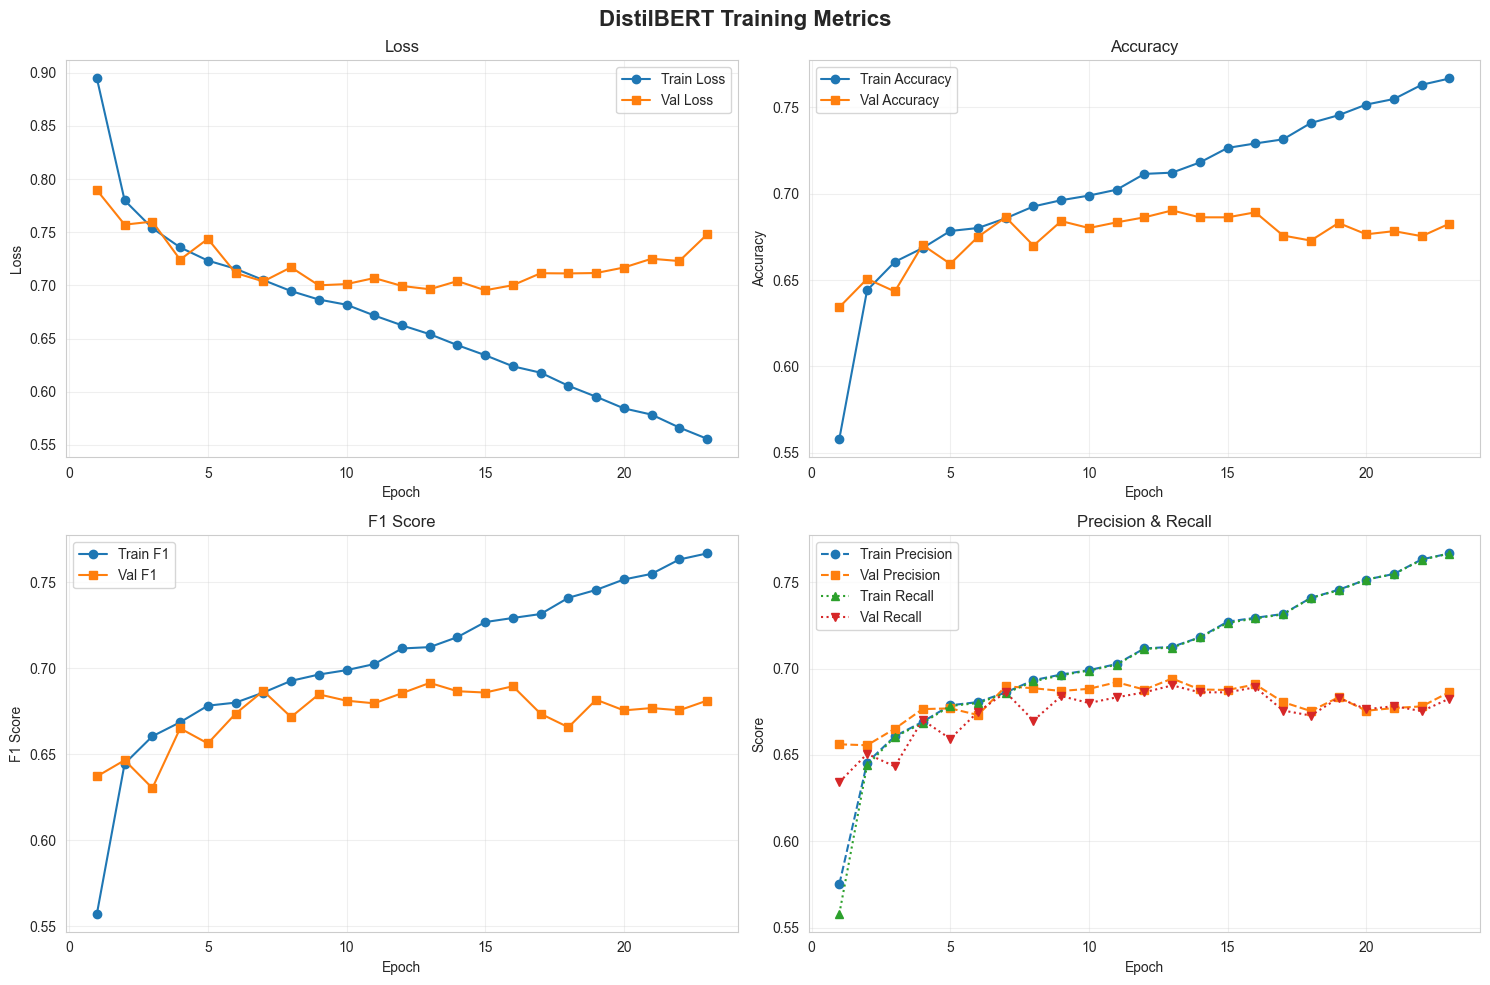

In [117]:
# Plot training metrics for each model
for model_name, tracker in all_metrics_trackers.items():
    plot_path = os.path.join(PIPELINE_METRICS_DIR, f"{model_name}_training_plot.png")
    tracker.plot_metrics(save_path=plot_path)

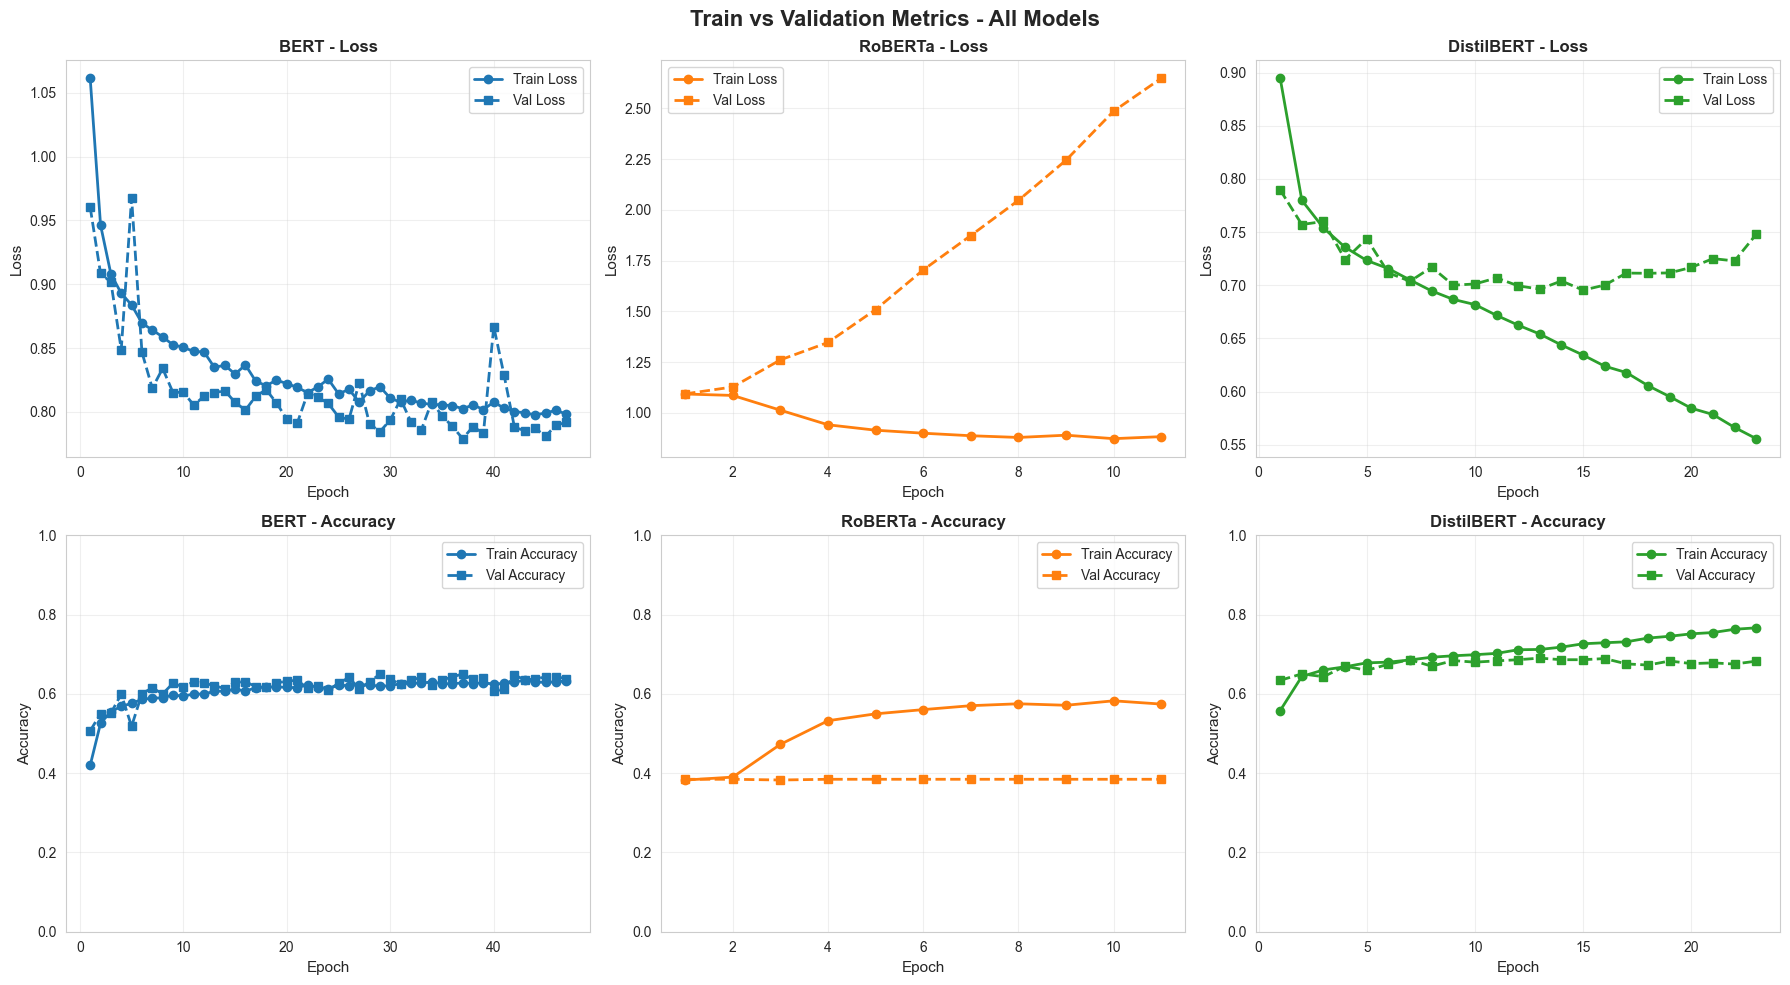

In [118]:
# Create train/val accuracy and loss curves for all models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Train vs Validation Metrics - All Models', fontsize=16, fontweight='bold')

model_names = list(all_metrics_trackers.keys())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for col_idx, model_name in enumerate(model_names):
    tracker = all_metrics_trackers[model_name]
    df = tracker.get_dataframe()
    
    # Loss plot
    axes[0, col_idx].plot(df['epoch'], df['train_loss'], label='Train Loss', marker='o', color=colors[col_idx], linestyle='-', linewidth=2)
    axes[0, col_idx].plot(df['epoch'], df['val_loss'], label='Val Loss', marker='s', color=colors[col_idx], linestyle='--', linewidth=2)
    axes[0, col_idx].set_xlabel('Epoch', fontsize=11)
    axes[0, col_idx].set_ylabel('Loss', fontsize=11)
    axes[0, col_idx].set_title(f'{model_name} - Loss', fontsize=12, fontweight='bold')
    axes[0, col_idx].legend(fontsize=10)
    axes[0, col_idx].grid(True, alpha=0.3)
    
    # Accuracy plot
    axes[1, col_idx].plot(df['epoch'], df['train_acc'], label='Train Accuracy', marker='o', color=colors[col_idx], linestyle='-', linewidth=2)
    axes[1, col_idx].plot(df['epoch'], df['val_acc'], label='Val Accuracy', marker='s', color=colors[col_idx], linestyle='--', linewidth=2)
    axes[1, col_idx].set_xlabel('Epoch', fontsize=11)
    axes[1, col_idx].set_ylabel('Accuracy', fontsize=11)
    axes[1, col_idx].set_title(f'{model_name} - Accuracy', fontsize=12, fontweight='bold')
    axes[1, col_idx].legend(fontsize=10)
    axes[1, col_idx].grid(True, alpha=0.3)
    axes[1, col_idx].set_ylim([0, 1.0])

plt.tight_layout()

# Save combined plot for all models
# train_val_plot_path = os.path.join(PIPELINE_METRICS_DIR, "all_models_train_val_curves.png")
# plt.savefig(train_val_plot_path, dpi=300, bbox_inches='tight')
# print(f"Saved train/val curves plot to {train_val_plot_path}")
# plt.show()

## 9. Compare Models

In [148]:
# Create summary comparison
results_df = pd.DataFrame(final_results).T
if len(results_df) > 0:
    results_df = results_df.sort_values('test_f1', ascending=False)

print("\n" + "="*80)
print("COMPARISON OF TEACHER MODELS")
print("="*80)
print(results_df[['test_acc', 'test_precision', 'test_recall', 'test_f1', 'training_time_s', 'size_mb', 'latency_ms']])


COMPARISON OF TEACHER MODELS
            test_acc test_precision test_recall   test_f1 training_time_s  \
DistilBERT  0.686795       0.693504    0.686795   0.68831        9.928654   
BERT        0.632957       0.641396    0.632957  0.634437       19.926224   
RoBERTa     0.384867       0.148123    0.384867  0.213916        9.728094   

             size_mb latency_ms  
DistilBERT  2.233356   0.004089  
BERT        2.233356   0.003863  
RoBERTa     2.233356   0.003493  


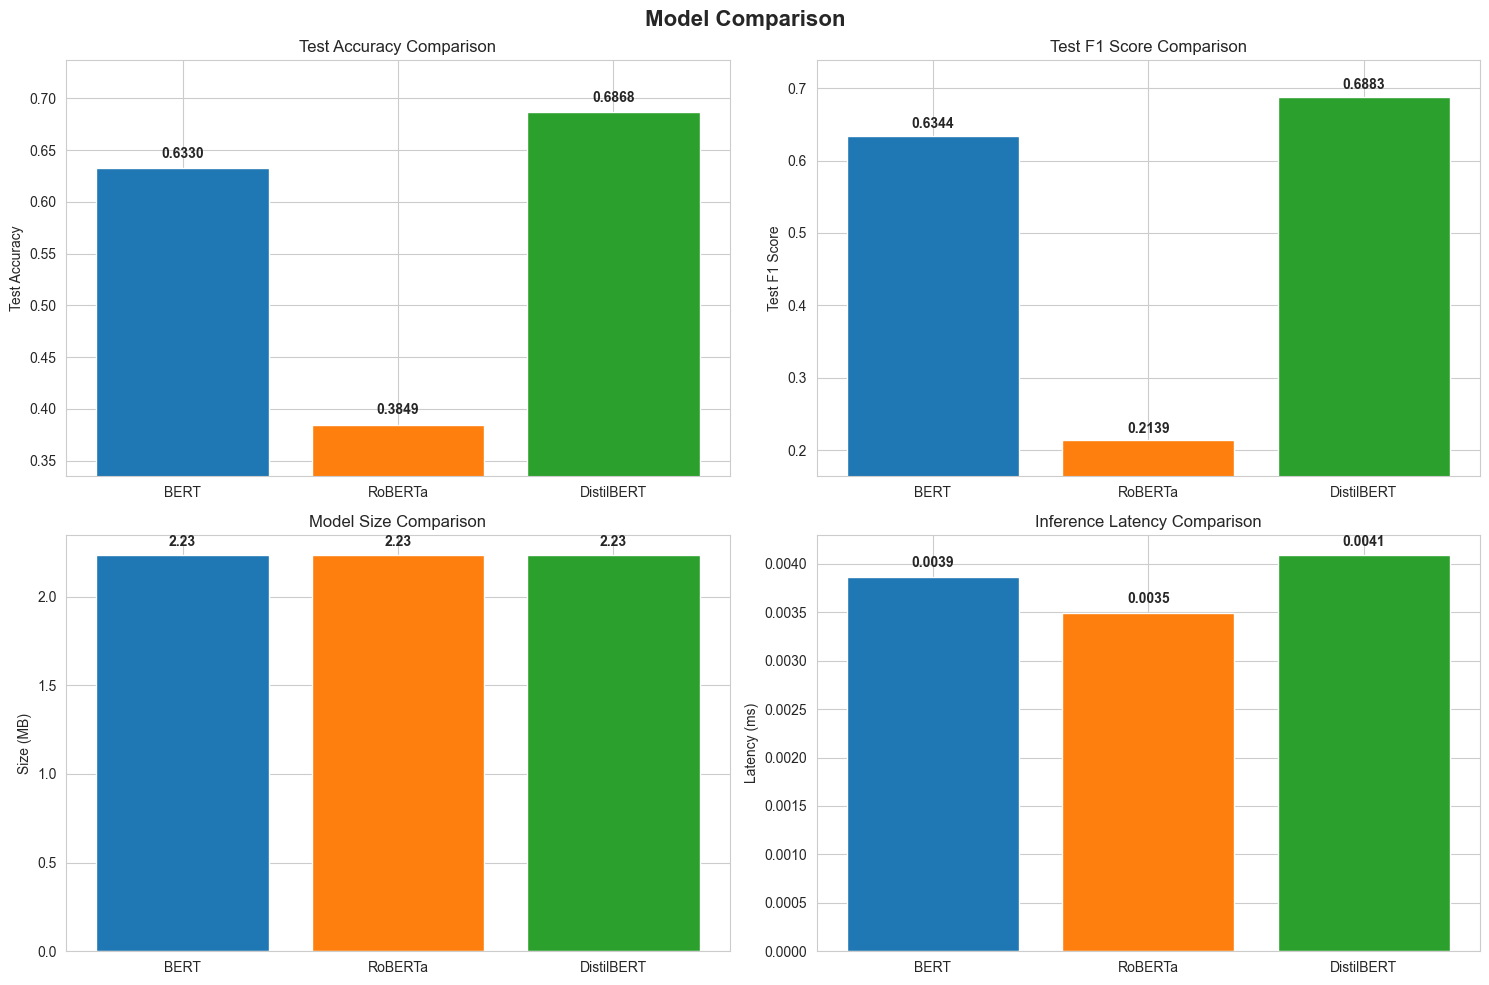

In [150]:
# Create comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Model Comparison', fontsize=16, fontweight='bold')

models = list(final_results.keys())
test_accs = [final_results[m]['test_acc'] for m in models]
test_f1s = [final_results[m]['test_f1'] for m in models]
sizes = [final_results[m]['size_mb'] for m in models]
latencies = [final_results[m]['latency_ms'] for m in models]

# Test Accuracy
axes[0, 0].bar(models, test_accs, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0, 0].set_ylabel('Test Accuracy')
axes[0, 0].set_title('Test Accuracy Comparison')
axes[0, 0].set_ylim([min(test_accs) - 0.05, max(test_accs) + 0.05])
for i, v in enumerate(test_accs):
    axes[0, 0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

# Test F1 Score
axes[0, 1].bar(models, test_f1s, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0, 1].set_ylabel('Test F1 Score')
axes[0, 1].set_title('Test F1 Score Comparison')
axes[0, 1].set_ylim([min(test_f1s) - 0.05, max(test_f1s) + 0.05])
for i, v in enumerate(test_f1s):
    axes[0, 1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

# Model Size
axes[1, 0].bar(models, sizes, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1, 0].set_ylabel('Size (MB)')
axes[1, 0].set_title('Model Size Comparison')
for i, v in enumerate(sizes):
    axes[1, 0].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

# Latency
axes[1, 1].bar(models, latencies, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1, 1].set_ylabel('Latency (ms)')
axes[1, 1].set_title('Inference Latency Comparison')
for i, v in enumerate(latencies):
    axes[1, 1].text(i, v + 0.0001, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
# comparison_plot_path = os.path.join(metrics_dir, "model_comparison.png")
# plt.savefig(comparison_plot_path, dpi=300, bbox_inches='tight')
# print(f"Saved model comparison plot to {comparison_plot_path}")
plt.show()

## 10. Distillation

### Feature Based Distillation

#### Class Definitons

In [121]:
class DistilledStudentModel(nn.Module):
    """
    Student model for feature-based distillation.
    Learns to mimic teacher's intermediate representations while predicting labels.
    """
    def __init__(self, input_dim, num_classes, hidden_dims, dropout=0.3):
        super().__init__()
        if not hidden_dims:
            raise ValueError("hidden_dims must contain at least one layer size")
        
        self.feature_layers = nn.ModuleList()
        self.activations = nn.ModuleList()
        self.dropouts = nn.ModuleList()
        
        # Build feature extraction layers
        dims = [input_dim] + list(hidden_dims)
        for idx in range(len(hidden_dims)):
            self.feature_layers.append(nn.Linear(dims[idx], dims[idx + 1]))
            self.activations.append(nn.ReLU())
            self.dropouts.append(nn.Dropout(dropout))
        
        # Classification head
        self.classifier = nn.Linear(hidden_dims[-1], num_classes)
    
    def forward(self, x, return_intermediate=False):
        """
        Forward pass with optional intermediate representations.
        Args:
            x: Input features
            return_intermediate: If True, return intermediate layer outputs
        Returns:
            logits or (logits, intermediate_features)
        """
        intermediates = []
        h = x
        
        for layer, activation, dropout in zip(self.feature_layers, self.activations, self.dropouts):
            h = layer(h)
            h = activation(h)
            intermediates.append(h)  # Store before dropout
            h = dropout(h)
        
        logits = self.classifier(h)
        
        if return_intermediate:
            return logits, intermediates
        return logits

In [122]:
class DistillationLoss(nn.Module):
    """
    Combined loss for feature-based distillation.

    Projection layers map each student intermediate layer to the corresponding
    teacher layer dimension before computing MSE, so distillation works even
    when student and teacher architectures differ in width (compression case).

    Layer pairing strategy: align from the deepest layer upward for
    min(n_student_layers, n_teacher_layers) pairs.
    """
    def __init__(self, student_dims, teacher_dims, alpha=0.5, temperature=1.0):
        """
        Args:
            student_dims: List of student hidden layer output dims e.g. [256, 128]
            teacher_dims: List of teacher hidden layer output dims e.g. [512, 256]
            alpha: Weight for distillation loss (1-alpha for task loss)
            temperature: Temperature for softening (reserved; not used in feature distillation)
        """
        super().__init__()
        self.alpha = alpha
        self.temperature = temperature
        self.ce_loss = nn.CrossEntropyLoss()
        self.mse_loss = nn.MSELoss()
        self.kl_loss = nn.KLDivLoss(reduction='batchmean')

        # Pair layers from the deepest end up to the number of available pairs
        n_pairs = min(len(student_dims), len(teacher_dims))
        self.n_pairs = n_pairs

        # One projection per pair: Linear(s_dim -> t_dim), or Identity if dims already match
        self.projections = nn.ModuleList()
        for i in range(n_pairs):
            s_dim = student_dims[-(n_pairs - i)]
            t_dim = teacher_dims[-(n_pairs - i)]
            if s_dim != t_dim:
                self.projections.append(nn.Linear(s_dim, t_dim, bias=False))
            else:
                self.projections.append(nn.Identity())

    def forward(self, student_logits, student_features, teacher_features, targets):
        """
        Compute combined distillation loss.
        Args:
            student_logits: Student model predictions
            student_features: List of student intermediate features
            teacher_features: List of teacher intermediate features (detached inside)
            targets: Ground truth labels
        Returns:
            total_loss, task_loss, distill_loss
        """
        # Task loss (cross-entropy)
        task_loss = self.ce_loss(student_logits, targets)

        # Feature distillation loss — align from deepest layer upward
        s_feats = student_features[-self.n_pairs:] if self.n_pairs > 0 else []
        t_feats = teacher_features[-self.n_pairs:] if self.n_pairs > 0 else []

        distill_loss = torch.tensor(0.0, device=student_logits.device)
        for proj, s_feat, t_feat in zip(self.projections, s_feats, t_feats):
            s_projected = proj(s_feat)
            distill_loss = distill_loss + self.mse_loss(s_projected, t_feat.detach())

        # Normalize by the number of matched pairs (not total student layers)
        if self.n_pairs > 0:
            distill_loss = distill_loss / self.n_pairs

        # Combine losses
        total_loss = (1 - self.alpha) * task_loss + self.alpha * distill_loss

        """
        # DistilBERT way of loss calculation
        
        T = self.temperature
        student_probs = F.log_softmax(student_logits / T, dim=-1)
        teacher_probs = F.softmax(teacher_logits / T, dim=-1)
        kd_loss = self.kl_loss(student_probs, teacher_probs) * (T * T)

        # Feature + cosine loss
        feature_loss = 0.0
        cosine_loss = 0.0

        for proj, s_feat, t_feat in zip(self.projections,
                                        student_features[-self.n_pairs:],
                                        teacher_features[-self.n_pairs:]):

            s_proj = proj(s_feat)

            feature_loss += self.mse_loss(s_proj, t_feat.detach())

            cosine_loss += (1 - F.cosine_similarity(
                s_proj, t_feat.detach(), dim=-1).mean())

        if self.n_pairs > 0:
            feature_loss /= self.n_pairs
            cosine_loss /= self.n_pairs

        total_loss = (
            0.3 * task_loss +
            0.4 * kd_loss +
            0.2 * feature_loss +
            0.1 * cosine_loss
        )
        """

        return total_loss, task_loss, distill_loss

In [123]:
class DistillationDataset(Dataset):
    """Dataset that provides input features, labels, and teacher intermediate features."""
    def __init__(self, features, labels, teacher_intermediates):
        self.features = features
        self.labels = labels
        self.teacher_intermediates = teacher_intermediates
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        teacher_feats = [layer_feat[idx] for layer_feat in self.teacher_intermediates]
        return self.features[idx], int(self.labels[idx]), teacher_feats

#### Intermediate layer extractor

In [124]:
def extract_teacher_intermediate_features(teacher_model, data_loader):
    """
    Extract intermediate features from a trained teacher model.
    Args:
        teacher_model: Trained FeatureClassifier model
        data_loader: DataLoader containing input features
    Returns:
        List of intermediate feature tensors for each layer
    """
    teacher_model.eval()
    all_intermediates = []
    
    with torch.no_grad():
        for x_batch, _ in data_loader:
            x_batch = x_batch.to(device)
            
            # Extract intermediate features by hooking into the network
            intermediates = []
            h = x_batch
            
            # Go through the sequential layers
            for i, layer in enumerate(teacher_model.net):
                h = layer(h)
                # Store activations after ReLU layers (before dropout)
                if isinstance(layer, nn.ReLU):
                    intermediates.append(h.detach().cpu())
            
            if len(all_intermediates) == 0:
                all_intermediates = [[] for _ in range(len(intermediates))]
            
            for idx, feat in enumerate(intermediates):
                all_intermediates[idx].append(feat)
    
    # Concatenate all batches for each layer
    all_intermediates = [torch.cat(layer_feats, dim=0) for layer_feats in all_intermediates]
    
    return all_intermediates


In [125]:
print("Extracting intermediate features from trained teacher models...")
teacher_intermediate_features = {}

for model_name in final_results.keys():
    print(f"\nProcessing {model_name}...")
    
    # Get the trained model configuration
    model_cfg = model_configs[model_name]
    hidden_dims = model_cfg["hidden_dims_options"][0]
    batch_size = model_cfg["batch_size_options"][0]
    
    train_feats = feature_cache[model_name]["train"]
    val_feats = feature_cache[model_name]["val"]
    test_feats = feature_cache[model_name]["test"]
    
    # Create data loaders
    train_loader = make_feature_loader(train_feats, y_train, batch_size=batch_size, shuffle=False)
    val_loader = make_feature_loader(val_feats, y_val, batch_size=batch_size, shuffle=False)
    test_loader = make_feature_loader(test_feats, y_test, batch_size=batch_size, shuffle=False)
    
    # Use the trained teacher model stored during teacher training
    teacher_model = trained_teacher_models[model_name]
    teacher_model.eval()
    print(f"  Using trained teacher model with hidden_dims={hidden_dims}")
    
    # Extract intermediate features from training, validation, and test sets
    teacher_intermediate_features[model_name] = {
        'train': extract_teacher_intermediate_features(teacher_model, train_loader),
        'val': extract_teacher_intermediate_features(teacher_model, val_loader),
        'test': extract_teacher_intermediate_features(teacher_model, test_loader)
    }
    
    print(f"  Extracted {len(teacher_intermediate_features[model_name]['train'])} intermediate layers")
    for idx, layer_feats in enumerate(teacher_intermediate_features[model_name]['train']):
        print(f"    Layer {idx}: {layer_feats.shape}")

print("\nIntermediate feature extraction complete!")


Extracting intermediate features from trained teacher models...

Processing BERT...
  Using trained teacher model with hidden_dims=[512, 256, 128]
  Extracted 3 intermediate layers
    Layer 0: torch.Size([21984, 512])
    Layer 1: torch.Size([21984, 256])
    Layer 2: torch.Size([21984, 128])

Processing RoBERTa...
  Using trained teacher model with hidden_dims=[512, 256, 128]
  Extracted 3 intermediate layers
    Layer 0: torch.Size([21984, 512])
    Layer 1: torch.Size([21984, 256])
    Layer 2: torch.Size([21984, 128])

Processing DistilBERT...
  Using trained teacher model with hidden_dims=[512, 256, 128]
  Extracted 3 intermediate layers
    Layer 0: torch.Size([21984, 512])
    Layer 1: torch.Size([21984, 256])
    Layer 2: torch.Size([21984, 128])

Intermediate feature extraction complete!


In [130]:
def make_distillation_loader(features, labels, teacher_intermediates, batch_size=64, shuffle=True):
    """Create DataLoader for distillation training."""
    ds = DistillationDataset(features, labels, teacher_intermediates)
    
    def collate_fn(batch):
        features = torch.stack([item[0] for item in batch])
        labels = torch.tensor([item[1] for item in batch])
        # Stack teacher features for each layer
        teacher_feats = []
        num_layers = len(batch[0][2])
        for layer_idx in range(num_layers):
            layer_batch = torch.stack([item[2][layer_idx] for item in batch])
            teacher_feats.append(layer_batch)
        return features, labels, teacher_feats
    
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, collate_fn=collate_fn)

In [131]:
def train_distillation_epoch(student_model, loader, optimizer, distill_criterion):
    """Train one epoch with feature-based distillation."""
    student_model.train()
    total_loss = 0.0
    total_task_loss = 0.0
    total_distill_loss = 0.0
    all_preds = []
    all_labels = []
    
    for x_batch, y_batch, teacher_feats in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        teacher_feats = [feat.to(device) for feat in teacher_feats]
        
        optimizer.zero_grad()
        
        # Forward pass with intermediate features
        student_logits, student_feats = student_model(x_batch, return_intermediate=True)
        
        # Compute distillation loss
        loss, task_loss, distill_loss = distill_criterion(
            student_logits, student_feats, teacher_feats, y_batch
        )
        
        loss.backward()
        if GRAD_CLIP > 0:
            torch.nn.utils.clip_grad_norm_(student_model.parameters(), GRAD_CLIP)
        optimizer.step()
        
        total_loss += loss.item() * x_batch.size(0)
        total_task_loss += task_loss.item() * x_batch.size(0)
        total_distill_loss += distill_loss.item() * x_batch.size(0)
        
        all_preds.append(torch.argmax(student_logits, dim=1).detach().cpu())
        all_labels.append(y_batch.detach().cpu())
    
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    metrics = compute_detailed_metrics(all_preds, all_labels)
    metrics['loss'] = total_loss / len(loader.dataset)
    metrics['task_loss'] = total_task_loss / len(loader.dataset)
    metrics['distill_loss'] = total_distill_loss / len(loader.dataset)
    
    return metrics

In [132]:
def eval_distillation_epoch(student_model, loader, distill_criterion):
    """Evaluate student model with distillation loss."""
    student_model.eval()
    total_loss = 0.0
    total_task_loss = 0.0
    total_distill_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for x_batch, y_batch, teacher_feats in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            teacher_feats = [feat.to(device) for feat in teacher_feats]
            
            student_logits, student_feats = student_model(x_batch, return_intermediate=True)
            
            loss, task_loss, distill_loss = distill_criterion(
                student_logits, student_feats, teacher_feats, y_batch
            )
            
            total_loss += loss.item() * x_batch.size(0)
            total_task_loss += task_loss.item() * x_batch.size(0)
            total_distill_loss += distill_loss.item() * x_batch.size(0)
            
            all_preds.append(torch.argmax(student_logits, dim=1).detach().cpu())
            all_labels.append(y_batch.detach().cpu())
    
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    metrics = compute_detailed_metrics(all_preds, all_labels)
    metrics['loss'] = total_loss / len(loader.dataset)
    metrics['task_loss'] = total_task_loss / len(loader.dataset)
    metrics['distill_loss'] = total_distill_loss / len(loader.dataset)
    
    return metrics

In [133]:
def train_distilled_student(
    student_model,
    train_loader,
    val_loader,
    optimizer,
    distill_criterion,
    epochs,
    patience=5,
    min_delta=0.0,
    verbose=True
):
    """Train student model with feature-based distillation."""
    best_state = copy.deepcopy(student_model.state_dict())
    best_val_acc = -1.0
    epochs_since_improve = 0
    history = []
    
    for epoch in range(1, epochs + 1):
        epoch_start = time.perf_counter()
        
        train_metrics = train_distillation_epoch(student_model, train_loader, optimizer, distill_criterion)
        val_metrics = eval_distillation_epoch(student_model, val_loader, distill_criterion)
        
        epoch_time = time.perf_counter() - epoch_start
        
        history.append({
            'epoch': epoch,
            'train_loss': train_metrics['loss'],
            'train_task_loss': train_metrics['task_loss'],
            'train_distill_loss': train_metrics['distill_loss'],
            'train_acc': train_metrics['acc'],
            'val_loss': val_metrics['loss'],
            'val_task_loss': val_metrics['task_loss'],
            'val_distill_loss': val_metrics['distill_loss'],
            'val_acc': val_metrics['acc'],
            'epoch_time': epoch_time
        })
        
        if verbose:
            print(
                f"Epoch {epoch:3d}/{epochs} | "
                f"train_loss={train_metrics['loss']:.4f} (task={train_metrics['task_loss']:.4f}, distill={train_metrics['distill_loss']:.4f}) "
                f"train_acc={train_metrics['acc']:.4f} | "
                f"val_loss={val_metrics['loss']:.4f} val_acc={val_metrics['acc']:.4f} | "
                f"time={epoch_time:.2f}s"
            )
        
        if val_metrics['acc'] > best_val_acc + min_delta:
            best_val_acc = val_metrics['acc']
            best_state = copy.deepcopy(student_model.state_dict())
            epochs_since_improve = 0
        else:
            epochs_since_improve += 1
            if epochs_since_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break
    
    return best_state, best_val_acc, history

#### Training Students

In [139]:
# Train distilled student models for each teacher
print("="*80)
print("TRAINING DISTILLED STUDENT MODELS")
print("="*80)

distillation_results = {}

# Load distillation parameters from config
distillation_alpha = DISTILLATION_ALPHA
distillation_temperature = DISTILLATION_TEMPERATURE

# Student model configuration from config file
student_hidden_dims = STUDENT_HIDDEN_DIMS
student_dropout = STUDENT_DROPOUT
student_lr = STUDENT_LR
student_batch_size = STUDENT_BATCH_SIZE
student_epochs = STUDENT_EPOCHS
student_patience = STUDENT_PATIENCE

print(f"Distillation Configuration (from config file):")
print(f"  Alpha: {distillation_alpha} (weight for distillation loss)")
print(f"  Temperature: {distillation_temperature}")
print(f"  Student Hidden Dims: {student_hidden_dims}")
print(f"  Student Dropout: {student_dropout}")
print(f"  Student Learning Rate: {student_lr}")
print(f"  Student Batch Size: {student_batch_size}")
print(f"  Student Epochs: {student_epochs}")
print(f"  Student Patience: {student_patience}")

TRAINING DISTILLED STUDENT MODELS
Distillation Configuration (from config file):
  Alpha: 0.5 (weight for distillation loss)
  Temperature: 1.0
  Student Hidden Dims: [256, 128, 64]
  Student Dropout: 0.3
  Student Learning Rate: 0.0003
  Student Batch Size: 64
  Student Epochs: 200
  Student Patience: 10


In [140]:
for model_name in final_results.keys():
    print(f"\n{'='*80}")
    print(f"Training distilled student for {model_name}")
    print(f"{'='*80}")
    
    # region - Get features, teacher intermediate features, and model dimensions for distillation setup
    # Get features
    train_feats = feature_cache[model_name]["train"]
    val_feats = feature_cache[model_name]["val"]
    test_feats = feature_cache[model_name]["test"]
    input_dim = train_feats.shape[1]
    
    # Get teacher intermediate features
    teacher_train_inter = teacher_intermediate_features[model_name]['train']
    teacher_val_inter = teacher_intermediate_features[model_name]['val']
    teacher_test_inter = teacher_intermediate_features[model_name]['test']
    
    # Get teacher hidden dims for projection layer setup
    teacher_hidden_dims = model_configs[model_name]["hidden_dims_options"][0]
    
    print(f"Input dimension: {input_dim}")
    print(f"Student architecture: {student_hidden_dims}")
    print(f"Teacher architecture: {teacher_hidden_dims}")
    print(f"Number of teacher intermediate layers: {len(teacher_train_inter)}")
    print(f"Distillation alpha: {distillation_alpha}")
    print()
    
    # Create distillation data loaders
    train_loader = make_distillation_loader(
        train_feats, y_train, teacher_train_inter,
        batch_size=student_batch_size, shuffle=True
    )
    val_loader = make_distillation_loader(
        val_feats, y_val, teacher_val_inter,
        batch_size=student_batch_size, shuffle=False
    )
    test_loader = make_distillation_loader(
        test_feats, y_test, teacher_test_inter,
        batch_size=student_batch_size, shuffle=False
    )
    
    # Initialize student model
    student_model = DistilledStudentModel(
        input_dim, num_classes,
        hidden_dims=student_hidden_dims,
        dropout=student_dropout
    ).to(device)

    # endregion
    

    # region - Initialize distillation criterion and optimizer
    # Initialize criterion first (contains trainable projection layers),
    # then build optimizer over student + projection parameters combined
    distill_criterion = DistillationLoss(
        student_dims=student_hidden_dims,
        teacher_dims=teacher_hidden_dims,
        alpha=distillation_alpha,
        temperature=distillation_temperature
    ).to(device)
    
    all_params = list(student_model.parameters()) + list(distill_criterion.parameters())
    opt = OPTIMIZER_NAME.strip().lower()
    if opt == "adam":
        optimizer = torch.optim.Adam(all_params, lr=student_lr)
    elif opt == "adamw":
        optimizer = torch.optim.AdamW(all_params, lr=student_lr)
    else:
        raise ValueError(f"Unsupported optimizer: {OPTIMIZER_NAME}")
    
    # endregion
    
    
    # region - Train student model with distillation
    # Train student model
    print(f"Training student model...")
    training_start = time.perf_counter()
    
    best_state, best_val_acc, history = train_distilled_student(
        student_model,
        train_loader,
        val_loader,
        optimizer,
        distill_criterion,
        epochs=student_epochs,
        patience=student_patience,
        min_delta=MIN_DELTA,
        verbose=True
    )
    
    training_time = time.perf_counter() - training_start
    
    # Load best model
    student_model.load_state_dict(best_state)
    
    # Evaluate on test set (without teacher features)
    print(f"\nEvaluating distilled {model_name} student on test set...")
    student_model.eval()
    test_preds = []
    test_labels = []
    
    with torch.no_grad():
        for x_batch, y_batch, _ in test_loader:
            x_batch = x_batch.to(device)
            logits = student_model(x_batch, return_intermediate=False)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            test_preds.append(preds)
            test_labels.append(y_batch.numpy())
    
    test_preds = np.concatenate(test_preds)
    test_labels = np.concatenate(test_labels)
    test_metrics = compute_detailed_metrics(test_preds, test_labels)
    
    # Measure latency
    latency_ms = measure_latency(student_model, test_feats, y_test, batch_size=LATENCY_BATCH_SIZE)
    
    # Calculate model size (student only, not projection layers)
    params = sum(p.numel() for p in student_model.parameters())
    size_mb = params * 4 / 1e6

    # endregion
    
    # Store results
    distillation_results[model_name] = {
        'config': {
            'hidden_dims': str(student_hidden_dims),
            'dropout': student_dropout,
            'lr': student_lr,
            'batch_size': student_batch_size,
            'alpha': distillation_alpha,
            'epochs': student_epochs,
            'patience': student_patience
        },
        'best_val_acc': best_val_acc,
        'test_acc': test_metrics['acc'],
        'test_precision': test_metrics['precision'],
        'test_recall': test_metrics['recall'],
        'test_f1': test_metrics['f1'],
        'training_time_s': training_time,
        'params': params,
        'size_mb': size_mb,
        'latency_ms': latency_ms,
        'epochs_trained': len(history),
        'history': history
    }
    
    print(f"\n{model_name} Distilled Student Results:")
    print(f"  Best Val Accuracy: {best_val_acc:.4f}")
    print(f"  Test Accuracy: {test_metrics['acc']:.4f}")
    print(f"  Test Precision: {test_metrics['precision']:.4f}")
    print(f"  Test Recall: {test_metrics['recall']:.4f}")
    print(f"  Test F1: {test_metrics['f1']:.4f}")
    print(f"  Training Time: {training_time:.2f}s")
    print(f"  Model Size: {size_mb:.2f} MB")
    print(f"  Latency: {latency_ms:.4f} ms")
    print(f"  Epochs Trained: {len(history)}")
    
    # Compare with original teacher
    teacher_test_acc = final_results[model_name]['test_acc']
    teacher_size_mb = final_results[model_name]['size_mb']
    teacher_latency_ms = final_results[model_name]['latency_ms']
    
    print(f"\n  Comparison with Teacher:")
    print(f"    Accuracy: {test_metrics['acc']:.4f} vs {teacher_test_acc:.4f} (diff: {test_metrics['acc'] - teacher_test_acc:+.4f})")
    print(f"    Model Size: {size_mb:.2f} MB vs {teacher_size_mb:.2f} MB (reduction: {(1 - size_mb/teacher_size_mb)*100:.1f}%)")
    print(f"    Latency: {latency_ms:.4f} ms vs {teacher_latency_ms:.4f} ms (speedup: {teacher_latency_ms/latency_ms:.2f}x)")

print("\n" + "="*80)
print("DISTILLATION TRAINING COMPLETE")
print("="*80)


Training distilled student for BERT
Input dimension: 768
Student architecture: [256, 128, 64]
Teacher architecture: [512, 256, 128]
Number of teacher intermediate layers: 3
Distillation alpha: 0.5

Training student model...
Epoch   1/200 | train_loss=0.5522 (task=1.0852, distill=0.0193) train_acc=0.3899 | val_loss=0.5299 val_acc=0.4414 | time=2.10s
Epoch   2/200 | train_loss=0.5012 (task=0.9910, distill=0.0115) train_acc=0.4897 | val_loss=0.4632 val_acc=0.5473 | time=1.18s
Epoch   3/200 | train_loss=0.4762 (task=0.9438, distill=0.0087) train_acc=0.5296 | val_loss=0.4535 val_acc=0.5633 | time=1.46s
Epoch   4/200 | train_loss=0.4648 (task=0.9221, distill=0.0076) train_acc=0.5446 | val_loss=0.4339 val_acc=0.5884 | time=1.13s
Epoch   5/200 | train_loss=0.4577 (task=0.9085, distill=0.0069) train_acc=0.5563 | val_loss=0.4304 val_acc=0.5968 | time=1.20s
Epoch   6/200 | train_loss=0.4513 (task=0.8961, distill=0.0064) train_acc=0.5699 | val_loss=0.4269 val_acc=0.6106 | time=1.29s
Epoch   7/200

In [141]:
duration = timedelta(seconds=time.perf_counter()-notebook_start_time)

## 11. Compare Teacher vs Distilled Student Models

In [142]:
# Create comprehensive comparison table
comparison_data = []

for model_name in final_results.keys():
    # Teacher results
    teacher_row = {
        'Model': f'{model_name} (Teacher)',
        'Type': 'Teacher',
        'Test Accuracy': final_results[model_name]['test_acc'],
        'Test F1': final_results[model_name]['test_f1'],
        'Parameters': final_results[model_name]['params'],
        'Size (MB)': final_results[model_name]['size_mb'],
        'Latency (ms)': final_results[model_name]['latency_ms'],
        'Training Time (s)': final_results[model_name]['training_time_s']
    }
    comparison_data.append(teacher_row)
    
    # Student results
    student_row = {
        'Model': f'{model_name} (Student)',
        'Type': 'Student',
        'Test Accuracy': distillation_results[model_name]['test_acc'],
        'Test F1': distillation_results[model_name]['test_f1'],
        'Parameters': distillation_results[model_name]['params'],
        'Size (MB)': distillation_results[model_name]['size_mb'],
        'Latency (ms)': distillation_results[model_name]['latency_ms'],
        'Training Time (s)': distillation_results[model_name]['training_time_s']
    }
    comparison_data.append(student_row)

comparison_df = pd.DataFrame(comparison_data)
print("Teacher vs Student Comparison:")
print(comparison_df.to_string(index=False))

Teacher vs Student Comparison:
               Model    Type  Test Accuracy  Test F1  Parameters  Size (MB)  Latency (ms)  Training Time (s)
      BERT (Teacher) Teacher       0.632957 0.634437      558339   2.233356      0.003863          19.926224
      BERT (Student) Student       0.624591 0.625830      238211   0.952844      0.003428          44.418321
   RoBERTa (Teacher) Teacher       0.384867 0.213916      558339   2.233356      0.003493           9.728094
   RoBERTa (Student) Student       0.384867 0.213916      238211   0.952844      0.003524          14.757700
DistilBERT (Teacher) Teacher       0.686795 0.688310      558339   2.233356      0.004089           9.928654
DistilBERT (Student) Student       0.688614 0.689656      238211   0.952844      0.003927          31.733862


In [143]:
# Calculate and display metrics
print("\nDistillation Effectiveness Metrics:")
print("-" * 80)
for model_name in final_results.keys():
    teacher_acc = final_results[model_name]['test_acc']
    student_acc = distillation_results[model_name]['test_acc']
    teacher_size = final_results[model_name]['size_mb']
    student_size = distillation_results[model_name]['size_mb']
    teacher_latency = final_results[model_name]['latency_ms']
    student_latency = distillation_results[model_name]['latency_ms']
    teacher_params = final_results[model_name]['params']
    student_params = distillation_results[model_name]['params']
    
    acc_retention = (student_acc / teacher_acc) * 100
    size_reduction = (1 - student_size / teacher_size) * 100
    speedup = teacher_latency / student_latency
    param_reduction = (1 - student_params / teacher_params) * 100
    
    print(f"\n{model_name}:")
    print(f"  Accuracy Retention: {acc_retention:.2f}% ({student_acc:.4f} vs {teacher_acc:.4f})")
    print(f"  Size Reduction: {size_reduction:.2f}% ({student_size:.2f} MB vs {teacher_size:.2f} MB)")
    print(f"  Parameter Reduction: {param_reduction:.2f}% ({student_params:,} vs {teacher_params:,})")
    print(f"  Speedup: {speedup:.2f}x ({student_latency:.4f} ms vs {teacher_latency:.4f} ms)")
    print(f"  Efficiency Ratio (Acc/Size): {student_acc/student_size:.4f} vs {teacher_acc/teacher_size:.4f}")


Distillation Effectiveness Metrics:
--------------------------------------------------------------------------------

BERT:
  Accuracy Retention: 98.68% (0.6246 vs 0.6330)
  Size Reduction: 57.34% (0.95 MB vs 2.23 MB)
  Parameter Reduction: 57.34% (238,211 vs 558,339)
  Speedup: 1.13x (0.0034 ms vs 0.0039 ms)
  Efficiency Ratio (Acc/Size): 0.6555 vs 0.2834

RoBERTa:
  Accuracy Retention: 100.00% (0.3849 vs 0.3849)
  Size Reduction: 57.34% (0.95 MB vs 2.23 MB)
  Parameter Reduction: 57.34% (238,211 vs 558,339)
  Speedup: 0.99x (0.0035 ms vs 0.0035 ms)
  Efficiency Ratio (Acc/Size): 0.4039 vs 0.1723

DistilBERT:
  Accuracy Retention: 100.26% (0.6886 vs 0.6868)
  Size Reduction: 57.34% (0.95 MB vs 2.23 MB)
  Parameter Reduction: 57.34% (238,211 vs 558,339)
  Speedup: 1.04x (0.0039 ms vs 0.0041 ms)
  Efficiency Ratio (Acc/Size): 0.7227 vs 0.3075


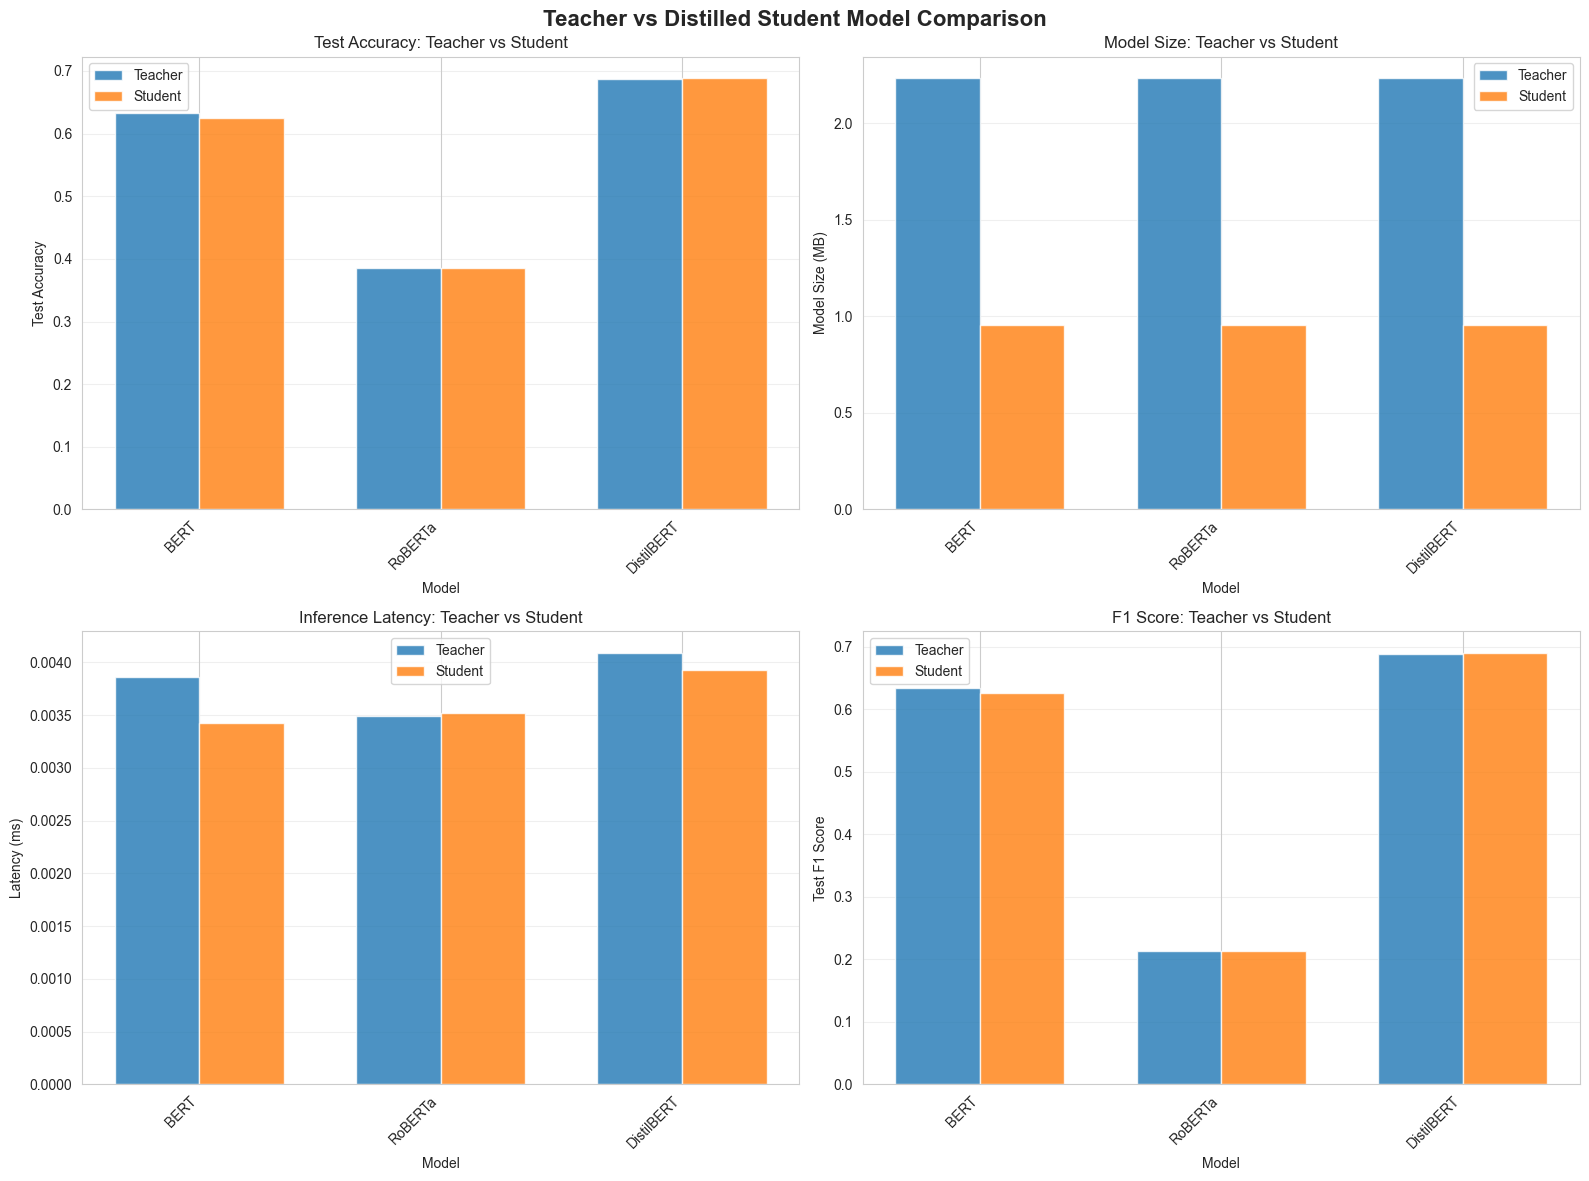

In [144]:
# Visualize Teacher vs Student Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Teacher vs Distilled Student Model Comparison', fontsize=16, fontweight='bold')

model_names = list(final_results.keys())
x_pos = np.arange(len(model_names))
width = 0.35

# 1. Accuracy Comparison
teacher_accs = [final_results[m]['test_acc'] for m in model_names]
student_accs = [distillation_results[m]['test_acc'] for m in model_names]

axes[0, 0].bar(x_pos - width/2, teacher_accs, width, label='Teacher', alpha=0.8)
axes[0, 0].bar(x_pos + width/2, student_accs, width, label='Student', alpha=0.8)
axes[0, 0].set_xlabel('Model')
axes[0, 0].set_ylabel('Test Accuracy')
axes[0, 0].set_title('Test Accuracy: Teacher vs Student')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(model_names, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Model Size Comparison
teacher_sizes = [final_results[m]['size_mb'] for m in model_names]
student_sizes = [distillation_results[m]['size_mb'] for m in model_names]

axes[0, 1].bar(x_pos - width/2, teacher_sizes, width, label='Teacher', alpha=0.8)
axes[0, 1].bar(x_pos + width/2, student_sizes, width, label='Student', alpha=0.8)
axes[0, 1].set_xlabel('Model')
axes[0, 1].set_ylabel('Model Size (MB)')
axes[0, 1].set_title('Model Size: Teacher vs Student')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(model_names, rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Latency Comparison
teacher_latencies = [final_results[m]['latency_ms'] for m in model_names]
student_latencies = [distillation_results[m]['latency_ms'] for m in model_names]

axes[1, 0].bar(x_pos - width/2, teacher_latencies, width, label='Teacher', alpha=0.8)
axes[1, 0].bar(x_pos + width/2, student_latencies, width, label='Student', alpha=0.8)
axes[1, 0].set_xlabel('Model')
axes[1, 0].set_ylabel('Latency (ms)')
axes[1, 0].set_title('Inference Latency: Teacher vs Student')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(model_names, rotation=45, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. F1 Score Comparison
teacher_f1s = [final_results[m]['test_f1'] for m in model_names]
student_f1s = [distillation_results[m]['test_f1'] for m in model_names]

axes[1, 1].bar(x_pos - width/2, teacher_f1s, width, label='Teacher', alpha=0.8)
axes[1, 1].bar(x_pos + width/2, student_f1s, width, label='Student', alpha=0.8)
axes[1, 1].set_xlabel('Model')
axes[1, 1].set_ylabel('Test F1 Score')
axes[1, 1].set_title('F1 Score: Teacher vs Student')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(model_names, rotation=45, ha='right')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
# plt.savefig('teacher_vs_student_comparison.png', dpi=300, bbox_inches='tight')
# print("Saved comparison plot to: teacher_vs_student_comparison.png")
plt.show()

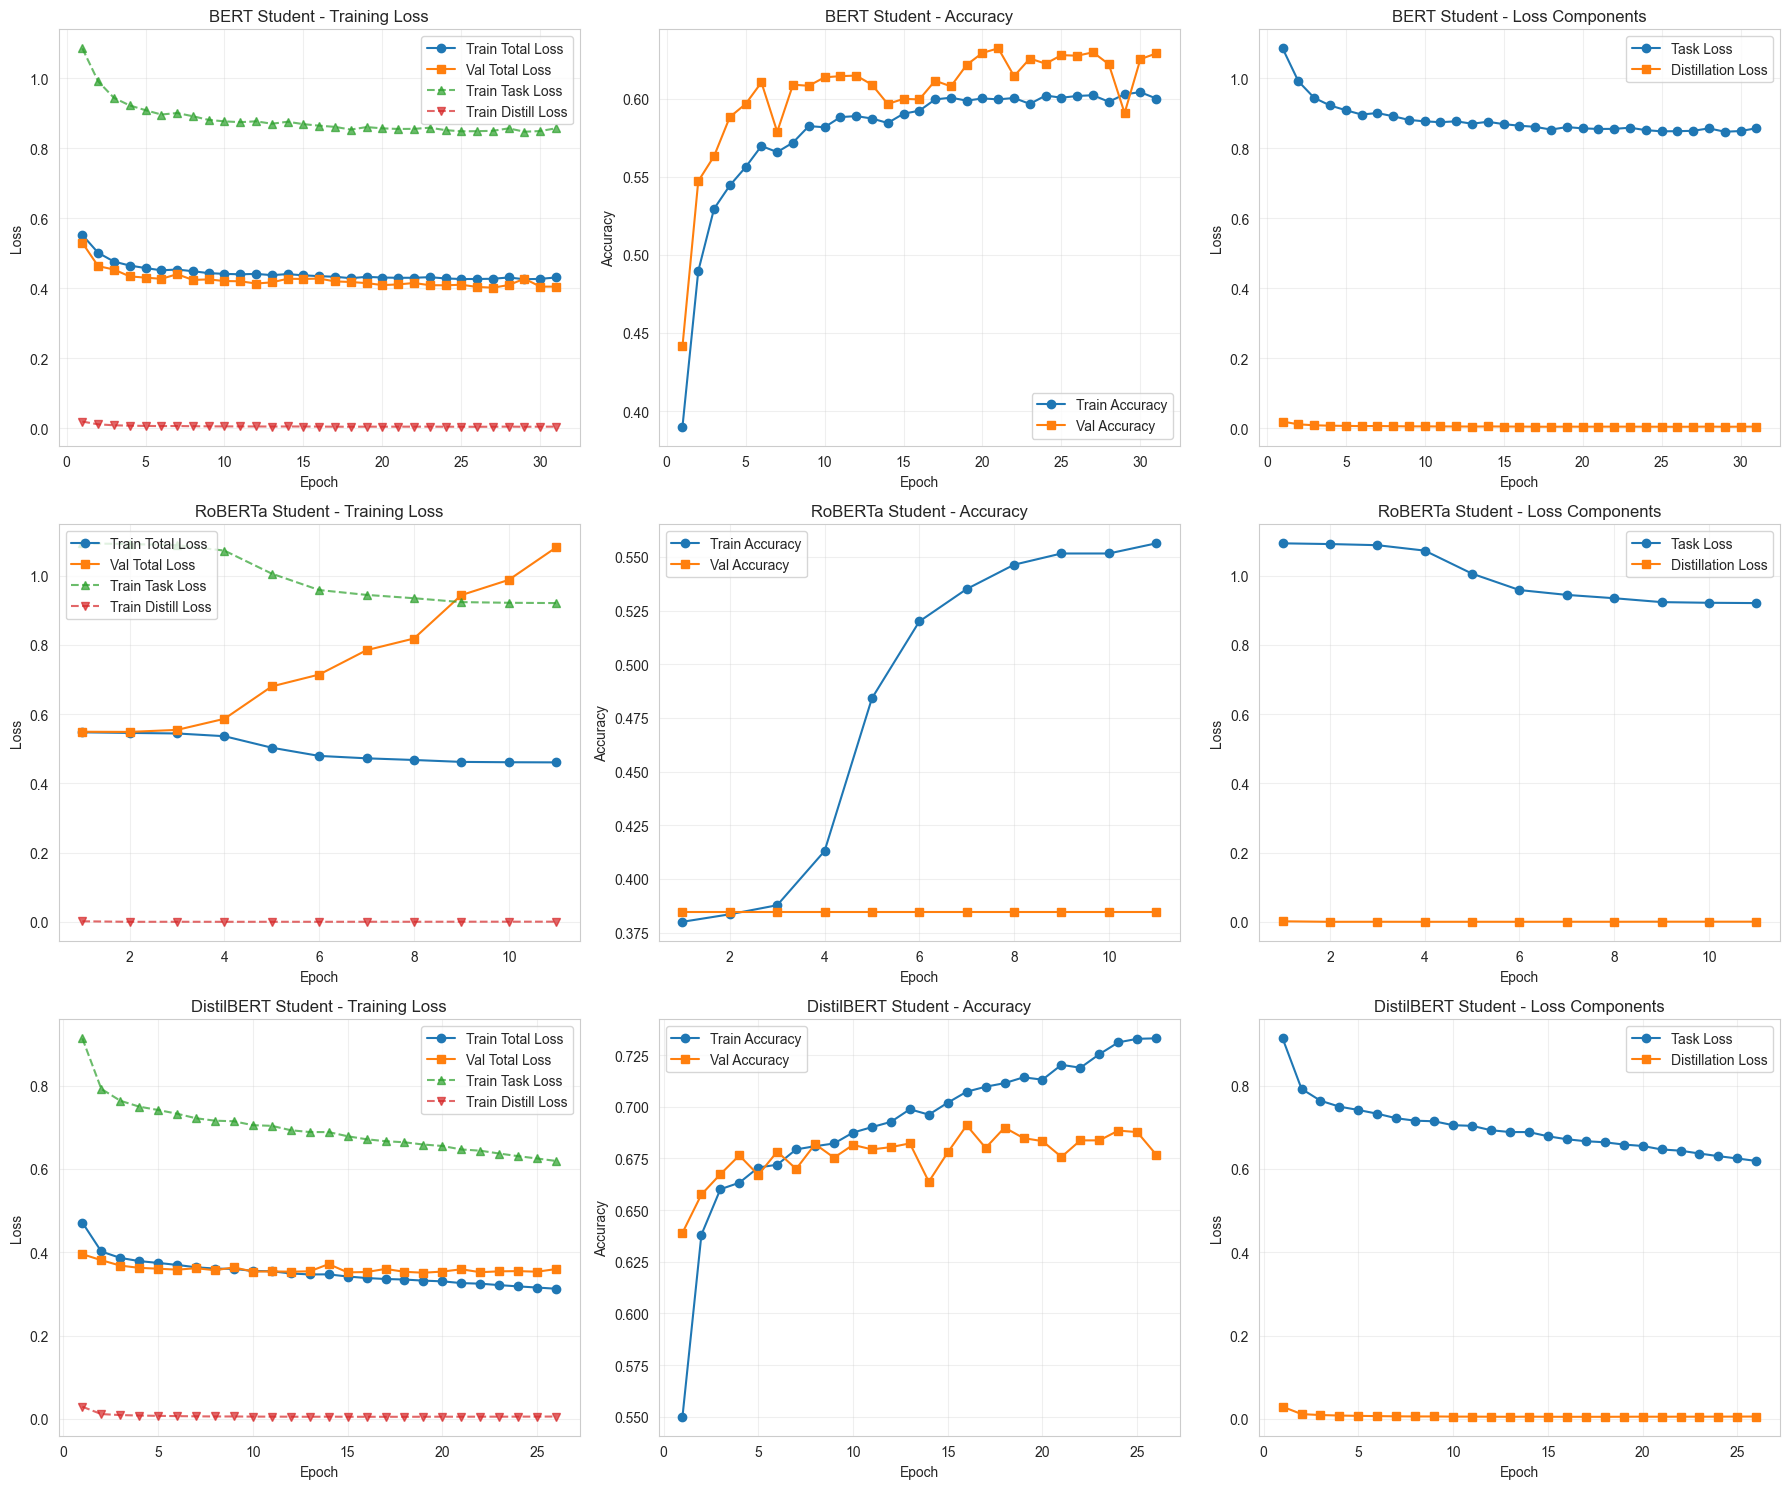

In [145]:
# Plot distillation training history for each student model
fig, axes = plt.subplots(len(model_names), 3, figsize=(18, 5 * len(model_names)))

if len(model_names) == 1:
    axes = axes.reshape(1, -1)

for idx, model_name in enumerate(model_names):
    history = distillation_results[model_name]['history']
    df_history = pd.DataFrame(history)
    
    # Loss plot
    axes[idx, 0].plot(df_history['epoch'], df_history['train_loss'], label='Train Total Loss', marker='o')
    axes[idx, 0].plot(df_history['epoch'], df_history['val_loss'], label='Val Total Loss', marker='s')
    axes[idx, 0].plot(df_history['epoch'], df_history['train_task_loss'], label='Train Task Loss', marker='^', linestyle='--', alpha=0.7)
    axes[idx, 0].plot(df_history['epoch'], df_history['train_distill_loss'], label='Train Distill Loss', marker='v', linestyle='--', alpha=0.7)
    axes[idx, 0].set_xlabel('Epoch')
    axes[idx, 0].set_ylabel('Loss')
    axes[idx, 0].set_title(f'{model_name} Student - Training Loss')
    axes[idx, 0].legend()
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Accuracy plot
    axes[idx, 1].plot(df_history['epoch'], df_history['train_acc'], label='Train Accuracy', marker='o')
    axes[idx, 1].plot(df_history['epoch'], df_history['val_acc'], label='Val Accuracy', marker='s')
    axes[idx, 1].set_xlabel('Epoch')
    axes[idx, 1].set_ylabel('Accuracy')
    axes[idx, 1].set_title(f'{model_name} Student - Accuracy')
    axes[idx, 1].legend()
    axes[idx, 1].grid(True, alpha=0.3)
    
    # Loss components breakdown
    axes[idx, 2].plot(df_history['epoch'], df_history['train_task_loss'], label='Task Loss', marker='o')
    axes[idx, 2].plot(df_history['epoch'], df_history['train_distill_loss'], label='Distillation Loss', marker='s')
    axes[idx, 2].set_xlabel('Epoch')
    axes[idx, 2].set_ylabel('Loss')
    axes[idx, 2].set_title(f'{model_name} Student - Loss Components')
    axes[idx, 2].legend()
    axes[idx, 2].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('distillation_training_history.png', dpi=300, bbox_inches='tight')
# print("Saved distillation training history plot to: distillation_training_history.png")
plt.show()

In [146]:
# Save distillation results to CSV
distillation_csv_path = "feature_distillation_results.csv"
# comparison_df.to_csv(distillation_csv_path, index=False)
# print(f"Saved distillation comparison results to {distillation_csv_path}")

# Save detailed distillation results
detailed_distillation = []
for model_name, results in distillation_results.items():
    row = {'model': f'{model_name}_distilled'}
    row.update(results['config'])
    row.update({k: v for k, v in results.items() if k not in ['config', 'history']})
    detailed_distillation.append(row)

detailed_distill_df = pd.DataFrame(detailed_distillation)
detailed_distill_csv_path = "feature_distillation_detailed_results.csv"
# detailed_distill_df.to_csv(detailed_distill_csv_path, index=False)
# print(f"Saved detailed distillation results to {detailed_distill_csv_path}")

# Save distillation training history for each model
distill_metrics_dir = "distillation_metrics"
os.makedirs(distill_metrics_dir, exist_ok=True)

for model_name, results in distillation_results.items():
    history_df = pd.DataFrame(results['history'])
    # history_path = os.path.join(distill_metrics_dir, f"{model_name}_distillation_history.csv")
    # history_df.to_csv(history_path, index=False)
    # print(f"Saved {model_name} distillation history to {history_path}")

# print("\nAll distillation results saved!")
# print(f"  - {distillation_csv_path}: Teacher vs Student comparison")
# print(f"  - {detailed_distill_csv_path}: Detailed student configurations and results")
# print(f"  - {distill_metrics_dir}/: Per-model distillation training histories")

## 12. Duration

In [147]:
# print the duration calculated
print(f"\nTotal notebook execution time: {duration}")


Total notebook execution time: 1:07:52.489274
